# libKriging vs SMT: Gradient-Enhanced Kriging (GEK)

Both libKriging and [SMT](https://smt.readthedocs.io/) (Surrogate Modeling
Toolbox) support conditioning a kriging model on **observed gradients**, not
just observed values — libKriging via `fit(..., grady=...)` (see
[`docs/math/gradient_kriging.md`](../math/gradient_kriging.md)), SMT via its
`GEKPLS` surrogate ([Bouhlel & Martins, 2019](https://doi.org/10.1007/s00366-018-0590-x)).

This notebook fits the same 2D test function with and without gradient
observations, in both packages, and compares:

1. out-of-sample RMSE at a fixed design size,
2. how RMSE decreases with the number of design points (value-only vs
   gradient-enhanced, in each package).

Both packages give the same qualitative result: a handful of gradient
observations buy accuracy that would otherwise need many more design
points.

## 0. Setup

In [1]:
# Run once: SMT is an external dependency, not part of libKriging.
%pip install -q smt matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
from pathlib import Path

# Point at the libKriging build directory containing the compiled
# _pylibkriging module and the pure-python `pylibkriging` package.
# Adjust REPO_ROOT / BUILD_DIR if your build lives elsewhere.
REPO_ROOT = Path.cwd().resolve().parents[1]
BUILD_DIR = REPO_ROOT / "build_gradk"  # or "build" / "build/installed", per your setup

sys.path.insert(0, str(BUILD_DIR / "bindings" / "Python" / "pylibkriging"))
sys.path.insert(0, str(REPO_ROOT / "bindings" / "Python" / "pylibkriging" / "src"))

import warnings

import numpy as np
import matplotlib.pyplot as plt

import pylibkriging as lk
from smt.surrogate_models import KRG, GEKPLS

# GEKPLS's internal PLS regression warns when a y-residual is ~constant at
# some iteration; harmless here (d=2, n_comp=2 -- no real reduction).
warnings.filterwarnings("ignore", message="y residual is constant")

print("pylibkriging", lk.__version__)

pylibkriging 1.1.0


## 1. Test function

A smooth 2D function with a known closed-form gradient, so both the design
and the out-of-sample test set can use exact derivatives (no finite
differences needed):

$$f(x_1, x_2) = \sin(3 x_1) + \cos(5 x_2), \qquad
\nabla f = \big(3\cos(3x_1),\; -5\sin(5x_2)\big)$$

In [3]:
def f(X):
    X = np.atleast_2d(X)
    return np.sin(3.0 * X[:, 0]) + np.cos(5.0 * X[:, 1])

def grad_f(X):
    X = np.atleast_2d(X)
    return np.stack([3.0 * np.cos(3.0 * X[:, 0]), -5.0 * np.sin(5.0 * X[:, 1])], axis=1)

rng = np.random.default_rng(0)

# Fixed, larger out-of-sample test set reused throughout the notebook.
X_test = rng.random((300, 2))
y_test = f(X_test)

## 2. Fit at a fixed design size (n=15)

In [4]:
n = 15
X = rng.random((n, 2))
y = f(X)
dy = grad_f(X)  # n x 2 observed gradients

# --- libKriging ---------------------------------------------------------
lk_plain = lk.Kriging(y, X, "gauss")
lk_grad = lk.Kriging(y, X, "gauss", grady=dy)

rmse_lk_plain = np.sqrt(np.mean((lk_plain.predict(X_test)[0].flatten() - y_test) ** 2))
rmse_lk_grad = np.sqrt(np.mean((lk_grad.predict(X_test)[0].flatten() - y_test) ** 2))

# --- SMT -----------------------------------------------------------------
smt_plain = KRG(print_global=False)
smt_plain.set_training_values(X, y)
smt_plain.train()

# n_comp=2: no PLS dimension reduction (d=2 here); extra_points=1 adds one
# extra design point per gradient direction using a first-order Taylor step,
# SMT's mechanism for injecting derivative information into a kriging fit.
smt_grad = GEKPLS(n_comp=2, extra_points=1, print_global=False)
smt_grad.set_training_values(X, y)
for kx in range(2):
    smt_grad.set_training_derivatives(X, dy[:, kx].reshape(-1, 1), kx)
smt_grad.train()

rmse_smt_plain = np.sqrt(np.mean((smt_plain.predict_values(X_test).flatten() - y_test) ** 2))
rmse_smt_grad = np.sqrt(np.mean((smt_grad.predict_values(X_test).flatten() - y_test) ** 2))

print(f"{'':20s} {'value-only':>12s} {'gradient-enhanced':>18s}")
print(f"{'libKriging':20s} {rmse_lk_plain:12.4f} {rmse_lk_grad:18.4f}")
print(f"{'SMT':20s} {rmse_smt_plain:12.4f} {rmse_smt_grad:18.4f}")

                       value-only  gradient-enhanced
libKriging                 0.0192             0.0013
SMT                        0.0192             0.0042


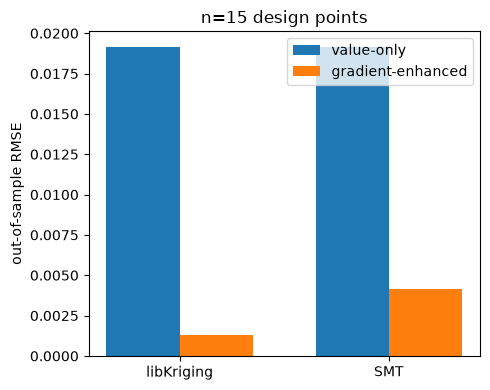

In [5]:
labels = ["libKriging", "SMT"]
plain_rmse = [rmse_lk_plain, rmse_smt_plain]
grad_rmse = [rmse_lk_grad, rmse_smt_grad]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(x - width / 2, plain_rmse, width, label="value-only")
ax.bar(x + width / 2, grad_rmse, width, label="gradient-enhanced")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("out-of-sample RMSE")
ax.set_title(f"n={n} design points")
ax.legend()
fig.tight_layout()

## 3. RMSE vs number of design points

Gradient observations are most valuable when function evaluations are scarce
relative to the input dimension. Repeat the fit across a range of `n` to see
each method's RMSE converge, with and without gradients.

In [6]:
n_values = [6, 10, 15, 25, 40]
n_repeats = 5  # average over random designs to smooth out sampling noise

results = {k: np.zeros((len(n_values), n_repeats)) for k in
           ["lk_plain", "lk_grad", "smt_plain", "smt_grad"]}

for i, n in enumerate(n_values):
    for r in range(n_repeats):
        rng_r = np.random.default_rng(1000 * n + r)
        Xr = rng_r.random((n, 2))
        yr = f(Xr)
        dyr = grad_f(Xr)

        m = lk.Kriging(yr, Xr, "gauss")
        results["lk_plain"][i, r] = np.sqrt(np.mean((m.predict(X_test)[0].flatten() - y_test) ** 2))

        m = lk.Kriging(yr, Xr, "gauss", grady=dyr)
        results["lk_grad"][i, r] = np.sqrt(np.mean((m.predict(X_test)[0].flatten() - y_test) ** 2))

        m = KRG(print_global=False)
        m.set_training_values(Xr, yr)
        m.train()
        results["smt_plain"][i, r] = np.sqrt(np.mean((m.predict_values(X_test).flatten() - y_test) ** 2))

        m = GEKPLS(n_comp=2, extra_points=1, print_global=False)
        m.set_training_values(Xr, yr)
        for kx in range(2):
            m.set_training_derivatives(Xr, dyr[:, kx].reshape(-1, 1), kx)
        m.train()
        results["smt_grad"][i, r] = np.sqrt(np.mean((m.predict_values(X_test).flatten() - y_test) ** 2))

means = {k: v.mean(axis=1) for k, v in results.items()}

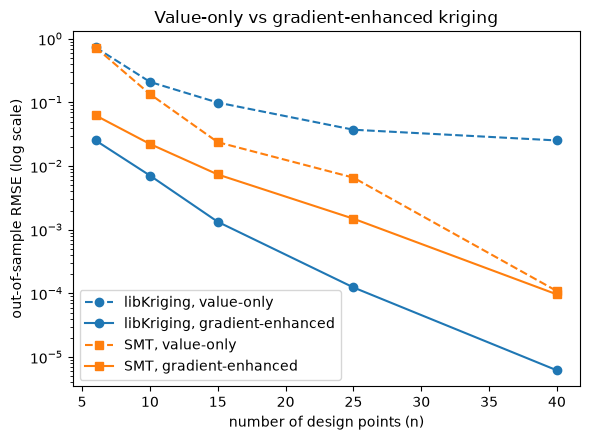

In [7]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(n_values, means["lk_plain"], "o--", color="tab:blue", label="libKriging, value-only")
ax.plot(n_values, means["lk_grad"], "o-", color="tab:blue", label="libKriging, gradient-enhanced")
ax.plot(n_values, means["smt_plain"], "s--", color="tab:orange", label="SMT, value-only")
ax.plot(n_values, means["smt_grad"], "s-", color="tab:orange", label="SMT, gradient-enhanced")
ax.set_yscale("log")
ax.set_xlabel("number of design points (n)")
ax.set_ylabel("out-of-sample RMSE (log scale)")
ax.set_title("Value-only vs gradient-enhanced kriging")
ax.legend()
fig.tight_layout()

## 4. Conclusion

At every design size tested, the gradient-enhanced fit dominates the
value-only fit **in both packages**, and closes most of the gap between a
small design and a much larger one. The two implementations agree
qualitatively; small differences in the exact RMSE (kernel/trend defaults,
SMT's `extra_points` Taylor-step mechanism vs libKriging's direct augmented
covariance, see [`docs/math/gradient_kriging.md`](../math/gradient_kriging.md))
are expected between independent implementations of the same idea.

### References

- Bouhlel, M. A., & Martins, J. R. R. A. (2019). *Gradient-enhanced kriging
  for high-dimensional problems*. Engineering with Computers, 35(1), 157-173.
  — GEKPLS, as implemented in SMT.
- Laurent, L., Le Riche, R., Soulier, B., & Boucard, P.-A. (2019). *An
  overview of gradient-enhanced metamodels with applications*. Archives of
  Computational Methods in Engineering, 26(1), 61-106.
- [SMT documentation: GEKPLS](https://smt.readthedocs.io/en/latest/_src_docs/surrogate_models/gekpls.html)
- [`docs/math/gradient_kriging.md`](../math/gradient_kriging.md) — libKriging's
  GEK formulation.